<a href="https://colab.research.google.com/github/Anamika-18/Project_Subsidy/blob/main/Project_subsidy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [195]:
#importing all packages for training

In [196]:

import matplotlib.pyplot as plt

In [197]:
import numpy as np

In [198]:
import pandas as pd

In [199]:
import seaborn as sns

In [200]:
from sklearn.model_selection import train_test_split

In [201]:
from sklearn.linear_model import LogisticRegression

In [202]:
from sklearn.metrics import accuracy_score , confusion_matrix

In [203]:
#importing data set

In [204]:
data_set = pd.read_csv('https://raw.githubusercontent.com/Anamika-18/Project_Subsidy/main/income(1).csv')

In [205]:
data = data_set.copy()

In [206]:
data['SalStat'].unique()

array([' less than or equal to 50,000', ' greater than 50,000'],
      dtype=object)

In [207]:
data['SalStat'] = data['SalStat'].str.strip()

In [208]:
data['SalStat'].unique()

array(['less than or equal to 50,000', 'greater than 50,000'],
      dtype=object)

In [209]:
#EDA: handle NAN and missing values

In [210]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        31978 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     31978 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB
None


In [211]:
summary_nums = data.describe()

In [212]:
summary_cate = data.describe(include = "O")

In [213]:
print(summary_nums , summary_cate)

                age   capitalgain   capitalloss  hoursperweek
count  31978.000000  31978.000000  31978.000000  31978.000000
mean      38.579023   1064.360623     86.739352     40.417850
std       13.662085   7298.596271    401.594301     12.345285
min       17.000000      0.000000      0.000000      1.000000
25%       28.000000      0.000000      0.000000     40.000000
50%       37.000000      0.000000      0.000000     40.000000
75%       48.000000      0.000000      0.000000     45.000000
max       90.000000  99999.000000   4356.000000     99.000000          JobType    EdType        maritalstatus       occupation relationship  \
count      31978     31978                31978            31978        31978   
unique         9        16                    7               15            6   
top      Private   HS-grad   Married-civ-spouse   Prof-specialty      Husband   
freq       22286     10368                14692             4038        12947   

          race gender   nativecountr

In [214]:
print(data.isnull().sum()) #no missing values in data

age              0
JobType          0
EdType           0
maritalstatus    0
occupation       0
relationship     0
race             0
gender           0
capitalgain      0
capitalloss      0
hoursperweek     0
nativecountry    0
SalStat          0
dtype: int64


In [215]:
#handling NAN

In [216]:
data['JobType'].value_counts()

,count
JobType,
Private,22286
Self-emp-not-inc,2499
Local-gov,2067
?,1809
State-gov,1279
Self-emp-inc,1074
Federal-gov,943
Without-pay,14
Never-worked,7


In [217]:
data['occupation'].value_counts()

,count
occupation,
Prof-specialty,4038
Craft-repair,4030
Exec-managerial,3992
Adm-clerical,3721
Sales,3584
Other-service,3212
Machine-op-inspct,1966
?,1816
Transport-moving,1572


In [218]:
#data preprocessing

In [219]:
data['JobType'] = data['JobType'].replace(' ?', np.nan)
data['occupation'] = data['occupation'].replace(' ?', np.nan)

In [220]:
data.isnull().sum()

,0
age,0
JobType,1809
EdType,0
maritalstatus,0
occupation,1816
relationship,0
race,0
gender,0
capitalgain,0
capitalloss,0


In [221]:
#jobtype = 1809 and occupation = 1816 , 7 values more of occupation are missing beacuse the jobtype is "never worked"

In [222]:
#in this particular case we are going to remove all the rows which have nan value and "never worked" because it will not contribute to the pridiction variable

In [223]:
data = data.dropna(subset=['JobType', 'occupation'])

In [224]:
data.isnull().sum()

,0
age,0
JobType,0
EdType,0
maritalstatus,0
occupation,0
relationship,0
race,0
gender,0
capitalgain,0
capitalloss,0


In [225]:
data['SalStat'].unique()

array(['less than or equal to 50,000', 'greater than 50,000'],
      dtype=object)

In [226]:
#done dealing with NAN values

In [227]:
# finding correlation between varibales

In [228]:
correlation = data.select_dtypes(include=['number']).corr()

In [229]:
print(correlation)

                   age  capitalgain  capitalloss  hoursperweek
age           1.000000     0.080154     0.060165      0.101599
capitalgain   0.080154     1.000000    -0.032229      0.080432
capitalloss   0.060165    -0.032229     1.000000      0.052417
hoursperweek  0.101599     0.080432     0.052417      1.000000


In [230]:
#since no value is near to 1 , we not no relationship between variables

In [231]:
#cross tables and visualizations

In [232]:
gender_salstats = pd.crosstab(index = data['gender'] , columns = data['SalStat'] , margins = True , normalize = "index")

In [233]:
print(gender_salstats)

SalStat  greater than 50,000  less than or equal to 50,000
gender                                                    
 Female             0.113678                      0.886322
 Male               0.313837                      0.686163
All                 0.248922                      0.751078


<Axes: xlabel='count', ylabel='SalStat'>

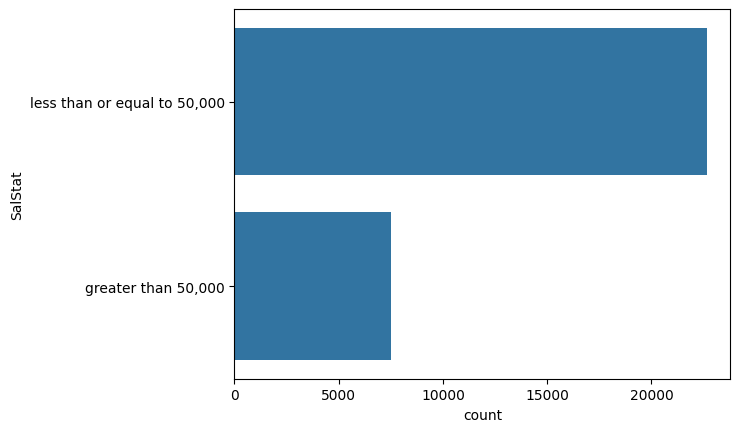

In [234]:
sns.countplot(data['SalStat'])

In [235]:
#75% have <= 50,000 salary

<Axes: xlabel='age', ylabel='Count'>

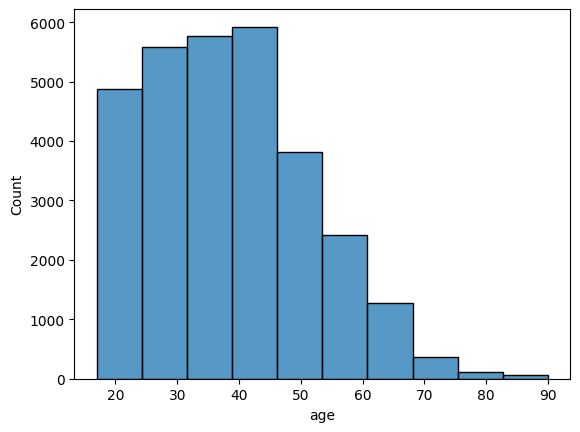

In [236]:
sns.histplot(data['age'] , kde = False , bins = 10)

<Axes: xlabel='SalStat', ylabel='age'>

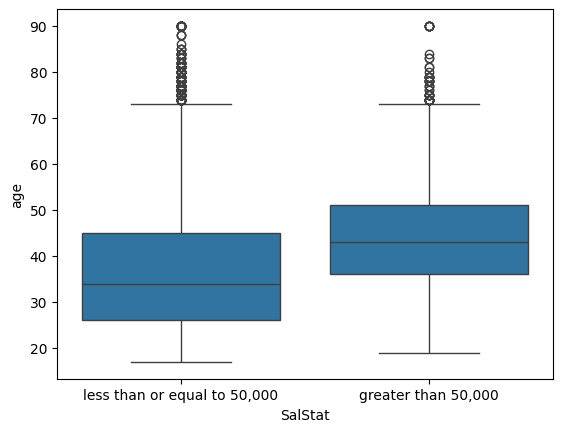

In [237]:
sns.boxplot(x='SalStat',y='age', data=data)

In [238]:
data.groupby('SalStat')['age'].median()

,age
SalStat,
"greater than 50,000",43.0
"less than or equal to 50,000",34.0


In [239]:
#interpretation: people with age 35-50 are more likely to earn more than 50,000

In [240]:
#more EDA on dataset:-

In [241]:
import matplotlib.pyplot as plt

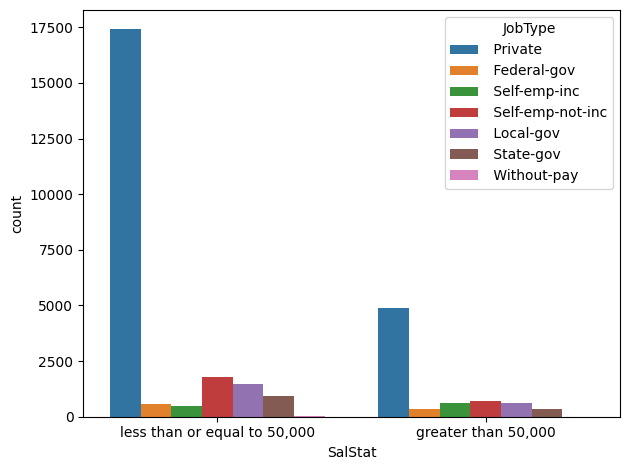

In [242]:
sns.countplot(x='SalStat', hue='JobType', data=data)
plt.tight_layout()


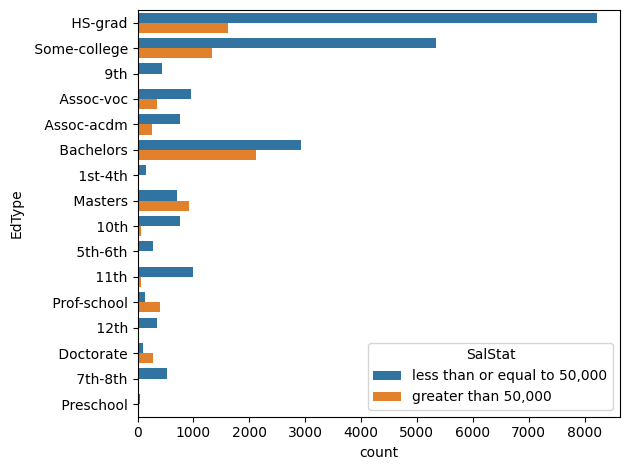

In [243]:
sns.countplot(y='EdType', hue='SalStat', data=data)

plt.tight_layout()

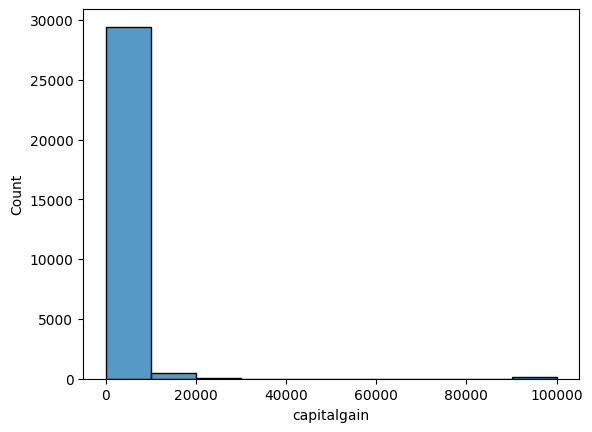

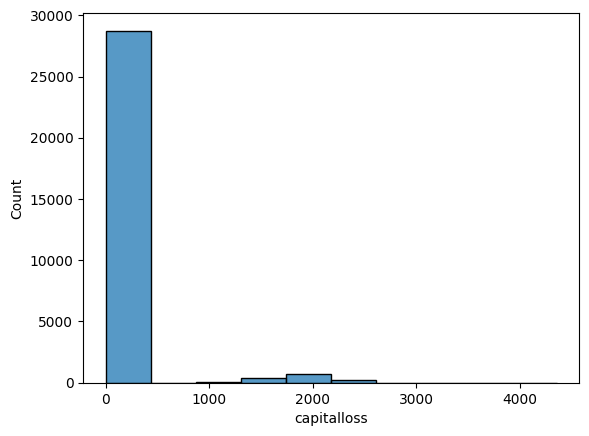

In [244]:
sns.histplot(data['capitalgain'], bins=10)
plt.show()

sns.histplot(data['capitalloss'], bins=10)
plt.show()

In [245]:
#92% of the capital gain id 0 and 95% of the capital loss is 0

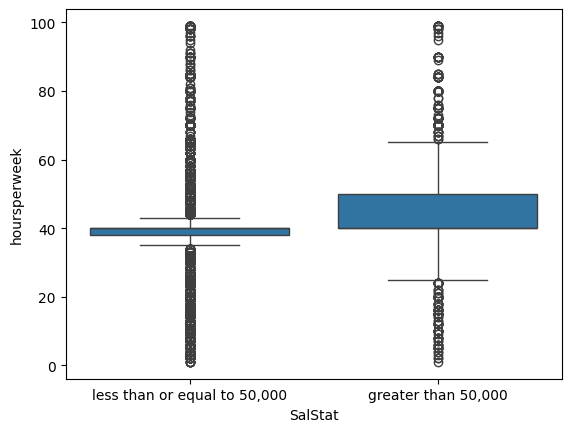

In [246]:
sns.boxplot(x='SalStat', y='hoursperweek', data=data)
plt.show()

In [247]:
#Insight1: People earning more than 50K tend to work more hours per week compared to those earning less.
#Insight2: High-income individuals show more variability in working hours.

In [248]:
data['SalStat'] = data['SalStat'].map({'less than or equal to 50,000': 0 , 'greater than 50,000':1})

In [249]:
data['SalStat'].unique()

array([0, 1])

In [250]:
new_data = pd.get_dummies(data, drop_first = True)

In [251]:
x = new_data.drop('SalStat', axis=1)
y = new_data['SalStat']

In [252]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=0)

In [253]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

In [254]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(train_x, train_y)

LogisticRegression(max_iter=1000)

In [255]:
prediction = model.predict(test_x)
pd.Series(prediction).value_counts()

,count
0,7233
1,1816


In [256]:
#the model has succesfully been trained and it has started predicting

In [257]:
#lets check the accuracy of our model

In [258]:
from sklearn.metrics import confusion_matrix
confusion_m = confusion_matrix(test_y, prediction)
print(confusion_m)

[[6316  507]
 [ 917 1309]]


In [259]:
from sklearn.metrics import accuracy_score
accuracy_score_value = accuracy_score(test_y, prediction)
print(accuracy_score_value)

0.8426345452536191


In [260]:
#our model is 84% accurate

In [261]:
#misclassified values :-
print((test_y != prediction).sum())

1424


Feature scaling in Logostic Regression : removing all insignificant features

In [262]:
data2 = data.copy()

In [263]:
data2['SalStat'].unique()

array([0, 1])

In [264]:
data2.describe()

,age,capitalgain,capitalloss,hoursperweek,SalStat
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238,0.248922
std,13.134665,7406.346497,404.298370,11.979984,0.432396
min,17.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,99999.000000,4356.000000,99.000000,1.000000


In [265]:
cols = [ 'gender' , 'nativecountry' , 'JobType' , 'race']
new_data = data2.drop(cols , axis=1)

In [266]:
new_data = pd.get_dummies(new_data, drop_first = True)

In [276]:
new_data.columns

Index(['age', 'capitalgain', 'capitalloss', 'hoursperweek', 'SalStat',
       'EdType_ 11th', 'EdType_ 12th', 'EdType_ 1st-4th', 'EdType_ 5th-6th',
       'EdType_ 7th-8th', 'EdType_ 9th', 'EdType_ Assoc-acdm',
       'EdType_ Assoc-voc', 'EdType_ Bachelors', 'EdType_ Doctorate',
       'EdType_ HS-grad', 'EdType_ Masters', 'EdType_ Preschool',
       'EdType_ Prof-school', 'EdType_ Some-college',
       'maritalstatus_ Married-AF-spouse', 'maritalstatus_ Married-civ-spouse',
       'maritalstatus_ Married-spouse-absent', 'maritalstatus_ Never-married',
       'maritalstatus_ Separated', 'maritalstatus_ Widowed',
       'occupation_ Armed-Forces', 'occupation_ Craft-repair',
       'occupation_ Exec-managerial', 'occupation_ Farming-fishing',
       'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct',
       'occupation_ Other-service', 'occupation_ Priv-house-serv',
       'occupation_ Prof-specialty', 'occupation_ Protective-serv',
       'occupation_ Sales', 'occupation

In [267]:
new_data.describe()

,age,capitalgain,capitalloss,hoursperweek,SalStat
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238,0.248922
std,13.134665,7406.346497,404.298370,11.979984,0.432396
min,17.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,99999.000000,4356.000000,99.000000,1.000000


In [268]:
x = new_data.drop('SalStat', axis=1)
y = new_data['SalStat']

In [269]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=0)

In [270]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

In [271]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(train_x, train_y)

LogisticRegression(max_iter=1000)

In [272]:
from sklearn.metrics import confusion_matrix
confusion_m = confusion_matrix(test_y, prediction)
print(confusion_m)

[[6316  507]
 [ 917 1309]]


In [273]:
from sklearn.metrics import accuracy_score
accuracy_score_value = accuracy_score(test_y, prediction)
print(accuracy_score_value)

0.8426345452536191


In [274]:
print((test_y != prediction).sum())

1424


In [277]:
#Removing certain categorical features did not impact the model accuracy, indicating they were not strong predictors. The model performance was more influenced by numerical and occupation-related features.

**KNN**

In [278]:
#Compared Logistic Regression with KNN to evaluate which model gives better performance.

In [279]:
#training:-

In [280]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_x, train_y)

KNeighborsClassifier()

In [281]:
#prediction:-

In [283]:
pred = knn.predict(test_x)
print(pred)

[0 0 0 ... 0 0 0]


In [284]:
#evalution metrics:-

In [285]:
cm = confusion_matrix(test_y,pred)
print(cm)

[[6153  670]
 [ 950 1276]]


In [288]:
ac = accuracy_score(test_y,pred)
print(ac)

0.8209746933362803


In [290]:
print((test_y != pred).sum())

1620


In [301]:
miss_sample = []

In [302]:
for i in range(1,20):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(train_x, train_y)
  pred_i = knn.predict(test_x)
  error = (test_y != pred_i).sum()
  miss_sample.append(error)
  print(f"K = {i}, Errors = {error}")

K = 1, Errors = 1875
K = 2, Errors = 1723
K = 3, Errors = 1637
K = 4, Errors = 1622
K = 5, Errors = 1620
K = 6, Errors = 1576
K = 7, Errors = 1567
K = 8, Errors = 1560
K = 9, Errors = 1568
K = 10, Errors = 1549
K = 11, Errors = 1556
K = 12, Errors = 1554
K = 13, Errors = 1549
K = 14, Errors = 1526
K = 15, Errors = 1528
K = 16, Errors = 1520
K = 17, Errors = 1531
K = 18, Errors = 1528
K = 19, Errors = 1543


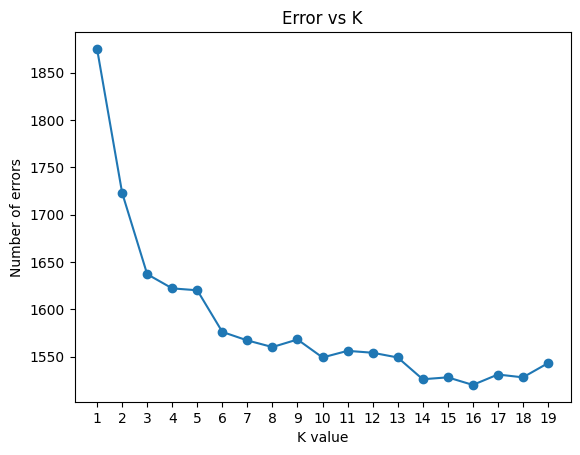

In [308]:
import matplotlib.pyplot as plt

plt.plot(range(1,20), miss_sample, marker='o')
plt.xlabel("K value")
plt.ylabel("Number of errors")
plt.title("Error vs K")

plt.xticks(range(1,20))

plt.show()

In [311]:
#16 gives the minimum number of errors hence being the best choice for k

This project focused on building an income classification model to predict whether an individual earns more than or less than 50,000 based on demographic and financial attributes.

During the initial phase, Exploratory Data Analysis (EDA) was performed to understand data distribution, detect missing values, and identify important features such as capital gain, hours per week, and education level.

Data preprocessing steps included handling missing values, encoding categorical variables using one-hot encoding, and feature scaling using standardization. Irrelevant features such as gender, race, native country, and job type were removed, as they did not significantly impact model performance.

Two machine learning models were implemented and compared:

Logistic Regression was used as a baseline model. However, it showed limitations due to class imbalance and linear assumptions.
K-Nearest Neighbors (KNN) was applied to capture non-linear relationships in the data. Hyperparameter tuning was performed by evaluating different values of K, and it was found that K = 16 provided the optimal performance with the lowest misclassification error.

The comparison of models showed that KNN performed better in capturing patterns in the dataset, while Logistic Regression provided a simpler and more interpretable baseline.

Overall, the project demonstrated the importance of data preprocessing, feature selection, and model tuning in improving prediction performance.

#end of script